In [15]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Analyse exploratoire des données

### Distribution

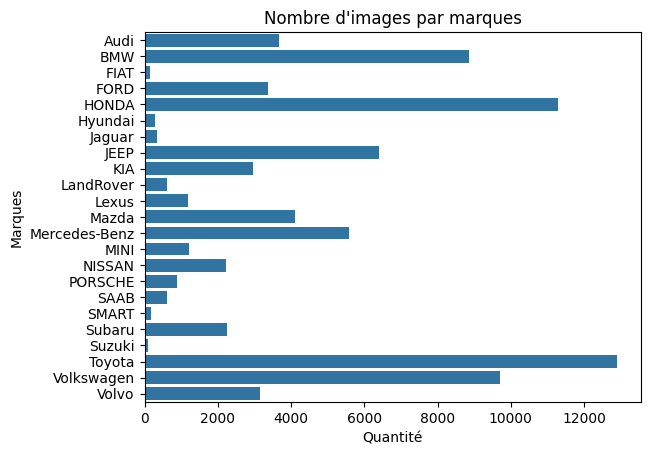

In [16]:
path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb'

#On récupère toutes les marques du dataset
marques = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]


#On compte le nombres d'images par marques
nb_pictures = []
for brand in os.listdir(path):
    brand_path=os.path.join(path, brand)
    if os.path.isdir(brand_path):
        num_images = len([f for f in os.listdir(brand_path) if os.path.isfile(os.path.join(brand_path, f))])
        nb_pictures.append(num_images)

#On affiche les résultats
plt.figure()
sns.barplot(x=nb_pictures, y=marques)
plt.title("Nombre d'images par marques")
plt.xlabel("Quantité")
plt.ylabel("Marques")
plt.show()


### Format des images

In [17]:
from PIL import Image


base_path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb' 
data_list = []


for marque in os.listdir(base_path):
    marque_path = os.path.join(base_path, marque)
    
    if os.path.isdir(marque_path):
        for img_name in os.listdir(marque_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(marque_path, img_name)
                
                try:
                    with Image.open(img_path) as img:
                        w, h = img.size
                        ratio = w / h
                        
                        data_list.append({
                            'marque': marque,
                            'nom': img_name,
                            'largeur': w,
                            'hauteur': h,
                            'ratio': round(ratio, 2)
                        })
                except Exception as e:
                    print(f"Erreur sur l'image {img_name}: {e}")

# 4. Création du DataFrame
df = pd.DataFrame(data_list)

# 5. Affichage des statistiques globales
print("\n--- Statistiques Générales ---")
print(df[['largeur', 'hauteur', 'ratio']].describe())

# 6. Repérer les "outliers" (images avec un ratio bizarre)
# Exemple : images beaucoup plus larges que hautes (ratio > 2)
print("\n--- Images très larges (Limo ou panoramique ?) ---")
print(df[df['ratio'] > 2.0].head())



--- Statistiques Générales ---
            largeur       hauteur         ratio
count  82008.000000  82008.000000  82008.000000
mean     520.349332    382.354429      1.367423
std      143.412625     80.892762      0.243364
min       50.000000     50.000000      0.540000
25%      412.000000    337.000000      1.330000
50%      588.000000    408.000000      1.340000
75%      600.000000    450.000000      1.340000
max     1760.000000    560.000000      3.230000

--- Images très larges (Limo ou panoramique ?) ---
    marque                                                nom  largeur  \
39    Audi  audi_a3_2006_2006 Audi A3_61goVu9xaXL._UY485_.jpg     1229   
40    Audi  audi_a3_2006_2006 Audi A3_81E1cL9oWvL._UY493_.png     1280   
41    Audi  audi_a3_2006_2006 Audi A3_81thEuPXWHL._UY560_.png     1187   
42    Audi  audi_a3_2006_2006 Audi A3_91eDsKngqiL._UY560_.png     1191   
123   Audi  audi_a3_2010_2010 Audi A3_71g8J6stRwL._UY560_.jpg     1129   

     hauteur  ratio  
39       485   2.

### Sanity Check

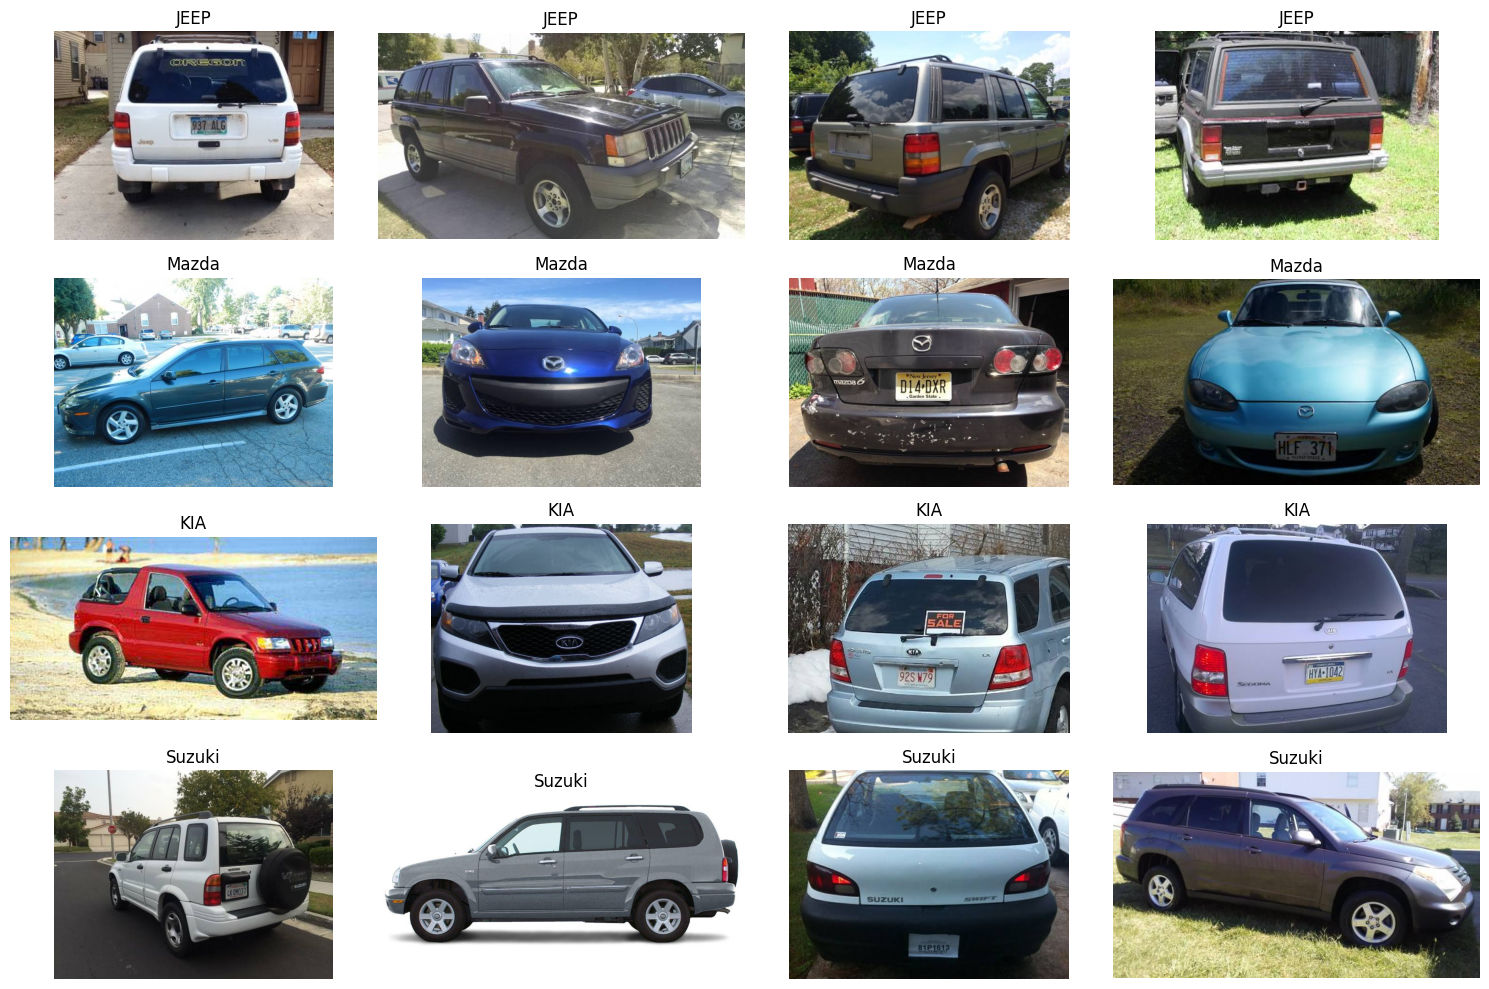

In [18]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# 1. Configuration
base_path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb'
nb_marques_a_voir = 4  # Nombre de lignes
images_par_marque = 4  # Nombre de colonnes

# 2. Récupérer la liste des marques (dossiers)
marques = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

# Sélectionner quelques marques au hasard pour l'inspection
marques_selectionnees = random.sample(marques, nb_marques_a_voir)

# 3. Création de la figure
fig, axes = plt.subplots(nb_marques_a_voir, images_par_marque, figsize=(15, 10))

for i, marque in enumerate(marques_selectionnees):
    marque_path = os.path.join(base_path, marque)
    
    # Lister les images dans ce dossier
    toutes_images = [f for f in os.listdir(marque_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    # Sélectionner des images au hasard
    echantillon = random.sample(toutes_images, min(images_par_marque, len(toutes_images)))
    
    for j, img_nom in enumerate(echantillon):
        img_path = os.path.join(marque_path, img_nom)
        
        try:
            img = Image.open(img_path)
            ax = axes[i, j]
            ax.imshow(img)
            ax.set_title(f"{marque}")
            ax.axis('off') # On cache les axes pour que ce soit plus propre
        except Exception as e:
            print(f"Erreur sur {img_nom}: {e}")

plt.tight_layout()
plt.show()

# Detecter les voitures avec ResNet-50

In [ ]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# Détection du GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {torch.cuda.get_device_name(device) if torch.cuda.is_available() else 'CPU'}")

# Chargement du modèle ResNet50 avec les poids ImageNet
ResNet50_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
ResNet50_model = ResNet50_model.to(device)
ResNet50_model.eval() # On le met en mode évaluation tout de suite

# Elle redimensionne, convertit en 0-1 (ToTensor) et applique la normalisation ImageNet
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Preprocessing

ResNet prend en entrée un tenseur 4D (un vecteur de cube de matrices), c'est à dire une grille d'image au format 224*224. Il faut donc les redimensionner. Le problème potentiel est que cette opération va déformer les images, ce qui peut induire le modèle en erreur. On verra pour une amélioration après les résultats des premiers test.





In [ ]:
def preprocess_image(img_path):
    """
    Transforme une image disque en un tenseur 4D (1, 3, 224, 224) prêt pour le GPU.
    """
    # 1. Charge l'image et s'assure du format RGB
    img = Image.open(img_path).convert('RGB')
    
    # 2. Applique la recette (Resize + ToTensor + Normalize)
    x = img_transform(img)
    
    # 3. Ajoute la dimension de batch (1, 3, 224, 224)
    return x.unsqueeze(0)

def paths_to_tensor(img_paths):
    """
    Prend une liste de chemins et les transforme en un seul gros bloc (Batch).
    """
    list_of_tensors = [preprocess_image(img_path) for img_path in tqdm(img_paths)]
    
    # On empile tout le monde sur la première dimension
    return torch.cat(list_of_tensors, dim=0)



ResNet renvoie un vecteur avec les probabilités d'appartenance aux 1000 classes d'ImageNet.

### Fonction de détection des voitures

In [ ]:
def car_detector(img_path):
    """
    Détecte si l'image à img_path contient une voiture.
    """
    # On récupère le tenseur déjà préparé
    img_tensor = preprocess_image(img_path).to(device)
    
    # Inférence
    with torch.no_grad():
        output = ResNet50_model(img_tensor)
        indice_predit = torch.argmax(output).item()
    
    # Vérification des indices car/truck/etc d'ImageNet
    car_indices = [436, 468, 511, 603, 627, 656, 751, 817]
    return indice_predit in car_indices

### Vérification du dataset


In [ ]:
from PIL import Image


base_path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb' 
not_car_counter = 0

for marque in os.listdir(base_path):
    marque_path = os.path.join(base_path, marque)
    
    if os.path.isdir(marque_path):
        for img_name in os.listdir(marque_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(marque_path, img_name)
                if not car_detector(img_path):
                    print("Objet autre détecté : ", img_path)
                    not_car_counter+=1
                                    

# Détecter les voitures avec YOLO

In [ ]:
import os
import cv2
from ultralytics import YOLO
from tqdm import tqdm

# Configuration des chemins
base_path = r'C:/Users/plled/Documents/SN2/PE/VMMRdb'
# IDs des classes COCO pour les véhicules : 2 (car), 5 (bus), 7 (truck)
target_classes = [2, 5, 7]
conf_threshold = 0.5

# Chargement du modèle sur la RTX 4050 (device=0)
# Le modèle nano est choisi pour sa vitesse sur 82 000 fichiers
model = YOLO('yolo11n.pt')

valid_cars = 0
invalid_files = 0
total_processed = 0

# Liste de tous les chemins d'images pour la barre de progression
image_paths = []
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

print(f"Début de l'analyse de {len(image_paths)} fichiers sur GPU...")

# Boucle de traitement avec barre de progression
for img_path in tqdm(image_paths, desc="Filtrage YOLO"):
    total_processed += 1
    
    # Inférence sur GPU
    results = model(img_path, device=0, verbose=False, conf=conf_threshold)
    
    found_vehicle = False
    for r in results:
        # On vérifie si l'une des détections appartient à nos classes cibles
        detected_classes = r.boxes.cls.tolist()
        if any(cls in target_classes for cls in detected_classes):
            found_vehicle = True
            break
            
    if found_vehicle:
        valid_cars += 1
    else:
        invalid_files += 1
        # Optionnel : log des fichiers non reconnus
        # print(f"Non-véhicule ou confiance faible : {img_path}")

# Résumé des statistiques
print("\n--- Rapport Final de Détection ---")
print(f"Total images analysées : {total_processed}")
print(f"Véhicules confirmés : {valid_cars}")
print(f"Images écartées : {invalid_files}")
print(f"Taux de validité : {(valid_cars/total_processed)*100:.2f}%")

# Modèle ResNet50

In [7]:

import torch
import torch.nn as nn
import torchvision.models as models
import os

### train/validation split

In [8]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torch.utils.data import WeightedRandomSampler

# On definit le chemin
base_path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb'

# Parametres de chargement
batch_size = 128  # Taille optimale pour 6Go de VRAM
img_size = (224, 224)
val_split = 0.2
seed = 123

# 1. TRANSFORMATIONS (Séparées et propres)
train_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), # <-- Appliqué une seule fois
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(), # <-- Appliqué une seule fois
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. CHARGEMENT EN DOUBLE 
# (Permet d'avoir des transformations différentes sans dupliquer les images sur le disque/RAM)
dataset_for_train = datasets.ImageFolder(root=base_path, transform=train_transforms)
dataset_for_val = datasets.ImageFolder(root=base_path, transform=val_transforms)

# 3. SPLIT TRAIN/VAL MANUEL
num_samples = len(dataset_for_train)
num_val = int(val_split * num_samples)
num_train = num_samples - num_val

generator = torch.Generator().manual_seed(seed)
indices = torch.randperm(num_samples, generator=generator).tolist()

train_ds = Subset(dataset_for_train, indices[:num_train])
val_ds = Subset(dataset_for_val, indices[num_train:])

# 4. CALCUL RAPIDE DES POIDS POUR LE SAMPLER
# On récupère les labels de l'entraînement
targets_tensor = torch.tensor([dataset_for_train.targets[i] for i in train_ds.indices])

# Compte les éléments par classe (bincount est 100x plus rapide qu'une boucle for)
class_sample_count = torch.bincount(targets_tensor)

# Calcul du poids : 1 / nombre d'échantillons
weight = 1. / class_sample_count.float()

# Assigne le poids à chaque image du dataset
samples_weight = weight[targets_tensor]

sampler = WeightedRandomSampler(
    weights=samples_weight, 
    num_samples=len(samples_weight), 
    replacement=True
)


train_loader = DataLoader(
    train_ds,
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=torch.cuda.is_available(),
    sampler=sampler 
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # <-- 0 ici aussi
    pin_memory=torch.cuda.is_available()
)

# Recuperation automatique du nombre de marques
class_names = dataset_for_train.classes
num_classes = len(class_names)
print(f"Nombre de marques detectees : {num_classes}")
print(f"Images entrainement : {num_train} | Images validation : {num_val}")

Nombre de marques detectees : 23
Images entrainement : 65607 | Images validation : 16401


### Préparer le modèle

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import copy

# 1. On prépare le modèle
def build_car_model(num_classes):
    # Charger ResNet50 avec les poids ImageNet
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    for name, param in model.named_parameters():
        if "layer4" in name or "fc" in name:
            param.requires_grad = True # On autorise l'entraînement ici
        else:
            param.requires_grad = False # Le reste reste gelé
    
    # Remplacer la dernière couche (la "tête")
    # En PyTorch, le pooling est déjà géré juste avant 'fc'
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes) # Pas de Softmax ici ! CrossEntropyLoss le fait tout seul
    )
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_car_model(num_classes).to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4) #On entraîne le dernier bloc et la tête

### Pénaliser l'erreur sur les plus petites classes

In [10]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


labels = train_ds.dataset.targets # On récupère les labels de l'entraînement pour calculer les poids de classe

# 2. On laisse Scikit-Learn calculer les poids idéaux
class_weights = compute_class_weight(
    class_weight='balanced', #'balanced' signifie que les poids seront inversément proportionnels à la fréquence de chaque classe
    classes=np.unique(labels), #np.unique(labels) donne la liste des classes présentes dans le dataset
    y=labels #y est la liste des étiquettes de chaque image (entiers correspondant à la classe)
)

# 3. On convertit en vecteur et on l'envoie sur le GPU
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device) 

# 4. On met à jour la fonction de perte 
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

### Execution du modèle

In [ ]:
epochs = 10
patience = 3 #nombre d'époques maximales sans amélioration
best_val_loss = float('inf') #on initialise la meilleure perte à l'infini pour la première comparaison
patience_counter = 0 #compteur d'époques sans amélioration
best_model_wts = copy.deepcopy(model.state_dict()) #photocopie des poids du modèle pour sauvegarder le meilleur

print("Démarrage de l'entraînement...")

for epoch in range(epochs): #on lance la boucle d'entraînement pour le nombre d'époques défini

    # --- PHASE D'ENTRAÎNEMENT ---

    model.train() #on met le modèle en mode entraînement pour activer les Dropout et BatchNorm
    train_loss = 0.0 #compteur de perte pour l'époque en cours
    
    for inputs, labels in train_loader: #on itère sur les batches du DataLoader. Chaque "inputs" est un batch d'images et "labels" les classes correspondantes
        inputs, labels = inputs.to(device), labels.to(device) #on envoie les données sur le GPU
        
        optimizer.zero_grad()           # on efface les gradients calculés lors de la passe précédente
        outputs = model(inputs)         # on donne les images au modèle pour obtenir les prédictions
        loss = criterion(outputs, labels) #calcul de la perte
        loss.backward()                 # Backward (Calcul des gradients)
        optimizer.step()                # Mise à jour des poids
        
        train_loss += loss.item() * inputs.size(0) #perte totale de l'époque (on multiplie par la taille du batch pour avoir la perte totale et pas la moyenne)

    # --- PHASE DE VALIDATION ---

    model.eval() #on met le modèle en mode évaluation pour désactiver les Dropout et BatchNorm
    #initialisation des compteurs de perte et de précision pour la validation
    val_loss = 0.0 
    corrects = 0
    
    with torch.no_grad(): #on désactive le calcul des gradients pour accélérer la validation et économiser de la mémoire
        for inputs, labels in val_loader: #on itère sur les batches de validation
            inputs, labels = inputs.to(device), labels.to(device) #on envoie les données sur le GPU
            outputs = model(inputs) #on donne les images au modèle pour obtenir les prédictions
            loss = criterion(outputs, labels) #calcul de la perte
            val_loss += loss.item() * inputs.size(0) #on accumule la perte totale de validation
            
            _, preds = torch.max(outputs, 1) #torch.max retourne la valeur max et son indice. On prend l'indice qui correspond à la classe prédite
            corrects += torch.sum(preds == labels.data) #on compare les prédictions avec les labels réels et on compte le nombre de bonnes réponses

    epoch_loss = val_loss / len(val_loader.dataset) #perte moyenne par image pour la validation
    epoch_acc = corrects.double() / len(val_loader.dataset) #précision moyenne pour la validation
    print(f"Epoch {epoch+1}/{epochs} | Val Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.4f}") #affichage de la perte et de la précision à chaque époque
    print(f"Train Loss: {train_loss/len(train_loader.dataset):.4f}") #affichage de la perte d'entraînement pour l'époque en cours

    # --- LOGIQUE DES CALLBACKS (Checkpoint & Early Stopping) ---
    if epoch_loss < best_val_loss: #si la perte de validation s'améliore, on sauvegarde le modèle et on réinitialise le compteur de patience
        best_val_loss = epoch_loss #on met à jour la meilleure perte
        best_model_wts = copy.deepcopy(model.state_dict()) #on sauvegarde les poids du modèle actuel comme le meilleur
        torch.save(model.state_dict(), 'best_car_model.pth') # on sauvegarde les poids du meilleur modèle sur le disque (ModelCheckpoint)
        patience_counter = 0 #on réinitialise le compteur de patience car on a une amélioration
        print("Nouveau meilleur modèle sauvegardé !")
    else:
        patience_counter += 1 #si pas d'amélioration, on incrémente le compteur de patience
        if patience_counter >= patience: #si on a atteint le nombre maximum d'époques sans amélioration, on arrête l'entraînement
            print("Early Stopping : La validation ne s'améliore plus.")
            break

# Charger les meilleurs poids à la fin
model.load_state_dict(best_model_wts) #on remet les poids du meilleur modèle trouvé pendant l'entraînement pour pouvoir l'utiliser ensuite (évaluation finale, export, etc)

# Optimisation du modèle ResNet50 avec Optuna

In [1]:
import os
import optuna
import torch
import torch.nn as nn
import torch.optim as optim 
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
from torch.utils.data import WeightedRandomSampler
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# On definit le chemin
base_path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb'

# Parametres de chargement
batch_size = 128  # Taille optimale pour 6Go de VRAM
img_size = (224, 224)
val_split = 0.2
seed = 123

# 1. TRANSFORMATIONS (Séparées et propres)
train_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), # <-- Appliqué une seule fois
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. CHARGEMENT EN DOUBLE 
# (Permet d'avoir des transformations différentes sans dupliquer les images sur le disque/RAM)
dataset_for_train = datasets.ImageFolder(root=base_path, transform=train_transforms)
dataset_for_val = datasets.ImageFolder(root=base_path, transform=val_transforms)

# 3. SPLIT TRAIN/VAL MANUEL
num_samples = len(dataset_for_train)
num_val = int(val_split * num_samples)
num_train = num_samples - num_val

generator = torch.Generator().manual_seed(seed)
indices = torch.randperm(num_samples, generator=generator).tolist()

train_ds = Subset(dataset_for_train, indices[:num_train])
val_ds = Subset(dataset_for_val, indices[num_train:])

# 4. CALCUL RAPIDE DES POIDS POUR LE SAMPLER
# On récupère les labels de l'entraînement
targets_tensor = torch.tensor([dataset_for_train.targets[i] for i in train_ds.indices])

# Compte les éléments par classe (bincount est 100x plus rapide qu'une boucle for)
class_sample_count = torch.bincount(targets_tensor)

# Calcul du poids : 1 / nombre d'échantillons
weight = 1. / class_sample_count.float()

# Assigne le poids à chaque image du dataset
samples_weight = weight[targets_tensor]

sampler = WeightedRandomSampler(
    weights=samples_weight, 
    num_samples=len(samples_weight), 
    replacement=True
)


train_loader = DataLoader(
    train_ds,
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=torch.cuda.is_available(),
    sampler=sampler 
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, 
    pin_memory=torch.cuda.is_available()
)

# Recuperation automatique du nombre de marques
class_names = dataset_for_train.classes
num_classes = len(class_names)
print(f"Nombre de marques detectees : {num_classes}")
print(f"Images entrainement : {num_train} | Images validation : {num_val}")

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

"""
all_labels = train_ds.dataset.targets # On récupère les labels de l'entraînement pour calculer les poids de classe

# 2. On laisse Scikit-Learn calculer les poids idéaux
class_weights = compute_class_weight(
    class_weight='balanced', #'balanced' signifie que les poids seront inversément proportionnels à la fréquence de chaque classe
    classes=np.unique(all_labels), #np.unique(all_labels) donne la liste des classes présentes dans le dataset
    y=all_labels #y est la liste des étiquettes de chaque image (entiers correspondant à la classe)
)


# 3. On convertit en vecteur et on l'envoie sur le GPU
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device) 
"""
# 4. On met à jour la fonction de perte 
criterion = nn.CrossEntropyLoss()


def objective(trial): 
    # 1. Hyperparamètres à optimiser
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True) #learning rate
    dropout = trial.suggest_float("dropout", 0.2, 0.7) #taux de Dropout à tester (min, max)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)  #Régularisation Ridge avec différents coefficients
    freeze_layer = trial.suggest_categorical("freeze_layer", ["layer4.2", "layer4.1", "layer4.0"]) #freeze une partie du bloc ou le bloc entier
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # 2. Rebuild le modèle avec ces hyperparamètres

    unfreeze_from = {
        "layer4.2": ["layer4.2.", "fc."],
        "layer4.1": ["layer4.1.", "layer4.2.", "fc."],
        "layer4.0": ["layer4.0.", "layer4.1.", "layer4.2.", "fc."]
    }

    prefixes = unfreeze_from[freeze_layer]

    for name, param in model.named_parameters():
        if any(name.startswith(p) for p in prefixes):
            param.requires_grad = True
        else:
            param.requires_grad = False

    num_ftrs = model.fc.in_features #on récupère le nombre de features en entrée de la tête pour pouvoir la remplacer
    model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(num_ftrs, num_classes)) #on remplace la tête par une nouvelle avec le taux de Dropout choisi et le nombre de classes à prédire
    model = model.to(device) #on envoie le modèle sur le GPU

    optimizer = optim.Adam( 
        filter(lambda p: p.requires_grad, model.parameters()), #on n'entraîne que les paramètres qui ont requires_grad=True
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5) #scheduler qui réduit le learning rate si la validation ne s'améliore pas pendant 2 époques

    # 3. Entraînement court (3 époques suffisent pour comparer)
    for epoch in range(5):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device) #on envoie les données sur le GPU
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels) #calcul de la perte
            loss.backward()                # Backward (Calcul des gradients)
            optimizer.step()            # Mise à jour des poids

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                val_loss += criterion(model(inputs), labels).item() * inputs.size(0)
        
        epoch_loss = val_loss / len(val_loader.dataset) #perte moyenne par image pour la validation
        scheduler.step(epoch_loss) #on informe le scheduler de la perte de validation pour qu'il puisse ajuster le learning rate si nécessaire

        # Pruning : coupe les essais peu prometteurs
        trial.report(epoch_loss, epoch)
        if trial.should_prune():
            del model, optimizer, inputs, labels, loss
            torch.cuda.empty_cache()
            raise optuna.exceptions.TrialPruned()
            
    del model, optimizer
    torch.cuda.empty_cache()

    return epoch_loss

# 4. Lancement
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
)
study.optimize(objective, n_trials=20)
print("Meilleurs hyperparamètres :", study.best_params)

Nombre de marques detectees : 23
Images entrainement : 65607 | Images validation : 16401


[I 2026-04-04 23:05:11,055] A new study created in memory with name: no-name-2d8955b5-2b21-47ce-9127-fc18603e5f0a
[I 2026-04-04 23:33:20,515] Trial 0 finished with value: 1.972162437456409 and parameters: {'lr': 1.0102336192116232e-05, 'dropout': 0.5999930902793871, 'weight_decay': 1.7483119151979473e-05, 'freeze_layer': 'layer4.2'}. Best is trial 0 with value: 1.972162437456409.
[I 2026-04-04 23:57:12,375] Trial 1 finished with value: 1.2371456909525664 and parameters: {'lr': 1.068631770340972e-05, 'dropout': 0.5026684224422768, 'weight_decay': 0.0020408891967963376, 'freeze_layer': 'layer4.1'}. Best is trial 1 with value: 1.2371456909525664.
[I 2026-04-05 00:21:33,748] Trial 2 finished with value: 0.7409151991608157 and parameters: {'lr': 0.0009953149604828126, 'dropout': 0.24288601868323983, 'weight_decay': 0.0015861641692672614, 'freeze_layer': 'layer4.0'}. Best is trial 2 with value: 0.7409151991608157.
[I 2026-04-05 00:45:52,935] Trial 3 finished with value: 0.37361790178665394 a

Meilleurs hyperparamètres : {'lr': 0.00025950393827819934, 'dropout': 0.5416202525218761, 'weight_decay': 4.751507773262611e-05, 'freeze_layer': 'layer4.0'}


# Execution du modèle avec les meilleurs hyperparamètres

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim 
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
from torch.utils.data import WeightedRandomSampler
from torchvision import datasets, transforms


# On definit le chemin
base_path = 'C:/Users/plled/Documents/SN2/PE/VMMRdb'

# Parametres de chargement
batch_size = 128  # Taille optimale pour 6Go de VRAM
img_size = (224, 224)
val_split = 0.2
seed = 123

# 1. TRANSFORMATIONS (Séparées et propres)
train_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), # <-- Appliqué une seule fois
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(), # <-- Appliqué une seule fois
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. CHARGEMENT EN DOUBLE 
# (Permet d'avoir des transformations différentes sans dupliquer les images sur le disque/RAM)
dataset_for_train = datasets.ImageFolder(root=base_path, transform=train_transforms)
dataset_for_val = datasets.ImageFolder(root=base_path, transform=val_transforms)

# 3. SPLIT TRAIN/VAL MANUEL
num_samples = len(dataset_for_train)
num_val = int(val_split * num_samples)
num_train = num_samples - num_val

generator = torch.Generator().manual_seed(seed)
indices = torch.randperm(num_samples, generator=generator).tolist()

train_ds = Subset(dataset_for_train, indices[:num_train])
val_ds = Subset(dataset_for_val, indices[num_train:])

# 4. CALCUL RAPIDE DES POIDS POUR LE SAMPLER
# On récupère les labels de l'entraînement
targets_tensor = torch.tensor([dataset_for_train.targets[i] for i in train_ds.indices])

# Compte les éléments par classe (bincount est 100x plus rapide qu'une boucle for)
class_sample_count = torch.bincount(targets_tensor)

# Calcul du poids : 1 / nombre d'échantillons
weight = 1. / class_sample_count.float()

# Assigne le poids à chaque image du dataset
samples_weight = weight[targets_tensor]

sampler = WeightedRandomSampler(
    weights=samples_weight, 
    num_samples=len(samples_weight), 
    replacement=True
)


train_loader = DataLoader(
    train_ds,
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=torch.cuda.is_available(),
    sampler=sampler 
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # <-- 0 ici aussi
    pin_memory=torch.cuda.is_available()
)

# Recuperation automatique du nombre de marques
class_names = dataset_for_train.classes
num_classes = len(class_names)
print(f"Nombre de marques detectees : {num_classes}")
print(f"Images entrainement : {num_train} | Images validation : {num_val}")

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import copy

# 1. On prépare le modèle
def build_car_model(num_classes):
    # Charger ResNet50 avec les poids ImageNet
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    for name, param in model.named_parameters():
        if "layer4" in name or "fc" in name:
            param.requires_grad = True # On autorise l'entraînement ici
        else:
            param.requires_grad = False # Le reste reste gelé
    
    # Remplacer la dernière couche (la "tête")
    # En PyTorch, le pooling est déjà géré juste avant 'fc'
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5416202525218761), #taux de Dropout optimisé trouvé par Optuna
        nn.Linear(num_ftrs, num_classes) # Pas de Softmax ici ! CrossEntropyLoss le fait tout seul
    )
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_car_model(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.00025950393827819934, weight_decay=4.751507773262611e-05) #On entraîne le dernier bloc et la tête
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)


epochs = 15
patience = 3 #nombre d'époques maximales sans amélioration
best_val_loss = float('inf') #on initialise la meilleure perte à l'infini pour la première comparaison
patience_counter = 0 #compteur d'époques sans amélioration
best_model_wts = copy.deepcopy(model.state_dict()) #photocopie des poids du modèle pour sauvegarder le meilleur

print("Démarrage de l'entraînement...")

for epoch in range(epochs): #on lance la boucle d'entraînement pour le nombre d'époques défini

    # --- PHASE D'ENTRAÎNEMENT ---

    model.train() #on met le modèle en mode entraînement pour activer les Dropout et BatchNorm
    train_loss = 0.0 #compteur de perte pour l'époque en cours
    
    for inputs, labels in train_loader: #on itère sur les batches du DataLoader. Chaque "inputs" est un batch d'images et "labels" les classes correspondantes
        inputs, labels = inputs.to(device), labels.to(device) #on envoie les données sur le GPU
        
        optimizer.zero_grad()           # on efface les gradients calculés lors de la passe précédente
        outputs = model(inputs)         # on donne les images au modèle pour obtenir les prédictions
        loss = criterion(outputs, labels) #calcul de la perte
        loss.backward()                 # Backward (Calcul des gradients)
        optimizer.step()                # Mise à jour des poids
        
        train_loss += loss.item() * inputs.size(0) #perte totale de l'époque (on multiplie par la taille du batch pour avoir la perte totale et pas la moyenne)

    # --- PHASE DE VALIDATION ---

    model.eval() #on met le modèle en mode évaluation pour désactiver les Dropout et BatchNorm
    #initialisation des compteurs de perte et de précision pour la validation
    val_loss = 0.0 
    corrects = 0
    
    with torch.no_grad(): #on désactive le calcul des gradients pour accélérer la validation et économiser de la mémoire
        for inputs, labels in val_loader: #on itère sur les batches de validation
            inputs, labels = inputs.to(device), labels.to(device) #on envoie les données sur le GPU
            outputs = model(inputs) #on donne les images au modèle pour obtenir les prédictions
            loss = criterion(outputs, labels) #calcul de la perte
            val_loss += loss.item() * inputs.size(0) #on accumule la perte totale de validation
            
            _, preds = torch.max(outputs, 1) #torch.max retourne la valeur max et son indice. On prend l'indice qui correspond à la classe prédite
            corrects += torch.sum(preds == labels.data) #on compare les prédictions avec les labels réels et on compte le nombre de bonnes réponses

    epoch_loss = val_loss / len(val_loader.dataset) #perte moyenne par image pour la validation
    epoch_acc = corrects.double() / len(val_loader.dataset) #précision moyenne pour la validation
    print(f"Epoch {epoch+1}/{epochs} | Val Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.4f}") #affichage de la perte et de la précision à chaque époque
    print(f"Train Loss: {train_loss/len(train_loader.dataset):.4f}") #affichage de la perte d'entraînement pour l'époque en cours
    scheduler.step(epoch_loss) #on informe le scheduler de la perte de validation pour qu'il puisse ajuster le learning rate si nécessaire
    
    # --- LOGIQUE DES CALLBACKS (Checkpoint & Early Stopping) ---
    if epoch_loss < best_val_loss: #si la perte de validation s'améliore, on sauvegarde le modèle et on réinitialise le compteur de patience
        best_val_loss = epoch_loss #on met à jour la meilleure perte
        best_model_wts = copy.deepcopy(model.state_dict()) #on sauvegarde les poids du modèle actuel comme le meilleur
        torch.save(model.state_dict(), 'best_car_model.pth') # on sauvegarde les poids du meilleur modèle sur le disque (ModelCheckpoint)
        patience_counter = 0 #on réinitialise le compteur de patience car on a une amélioration
        print("Nouveau meilleur modèle sauvegardé !")
    else:
        patience_counter += 1 #si pas d'amélioration, on incrémente le compteur de patience
        if patience_counter >= patience: #si on a atteint le nombre maximum d'époques sans amélioration, on arrête l'entraînement
            print("Early Stopping : La validation ne s'améliore plus.")
            break

# Charger les meilleurs poids à la fin
model.load_state_dict(best_model_wts) #on remet les poids du meilleur modèle trouvé pendant l'entraînement pour pouvoir l'utiliser ensuite (évaluation finale, export, etc)

Nombre de marques detectees : 23
Images entrainement : 65607 | Images validation : 16401
Démarrage de l'entraînement...
Epoch 1/15 | Val Loss: 0.6679 | Val Acc: 0.7880
Train Loss: 0.8557
Nouveau meilleur modèle sauvegardé !
Epoch 2/15 | Val Loss: 0.5326 | Val Acc: 0.8343
Train Loss: 0.3368
Nouveau meilleur modèle sauvegardé !
Epoch 3/15 | Val Loss: 0.4954 | Val Acc: 0.8506
Train Loss: 0.2442
Nouveau meilleur modèle sauvegardé !
Epoch 4/15 | Val Loss: 0.4229 | Val Acc: 0.8685
Train Loss: 0.1914
Nouveau meilleur modèle sauvegardé !
Epoch 5/15 | Val Loss: 0.3910 | Val Acc: 0.8838
Train Loss: 0.1621
Nouveau meilleur modèle sauvegardé !
Epoch 6/15 | Val Loss: 0.4012 | Val Acc: 0.8821
Train Loss: 0.1410
Epoch 7/15 | Val Loss: 0.3414 | Val Acc: 0.9020
Train Loss: 0.1271
Nouveau meilleur modèle sauvegardé !
Epoch 8/15 | Val Loss: 0.4215 | Val Acc: 0.8771
Train Loss: 0.1201
Epoch 9/15 | Val Loss: 0.3572 | Val Acc: 0.8940
Train Loss: 0.1125
Epoch 10/15 | Val Loss: 0.3566 | Val Acc: 0.8994
Train 

<All keys matched successfully>

Évaluation du modèle en cours sur le jeu de validation... Cela peut prendre quelques secondes.

📊 RAPPORT DE CLASSIFICATION
               precision    recall  f1-score   support

         Audi       0.91      0.93      0.92       715
          BMW       0.85      0.97      0.91      1750
         FIAT       0.89      0.96      0.93        26
         FORD       0.94      0.90      0.92       658
        HONDA       0.89      0.91      0.90      2214
      Hyundai       0.81      0.88      0.84        58
         JEEP       0.98      0.97      0.98      1286
       Jaguar       0.69      0.93      0.80        73
          KIA       0.92      0.87      0.89       635
    LandRover       0.94      0.93      0.93       108
        Lexus       0.65      0.92      0.76       231
         MINI       0.99      0.98      0.99       236
        Mazda       0.92      0.82      0.86       870
Mercedes-Benz       0.91      0.91      0.91      1118
       NISSAN       0.95      0.85      0.90      

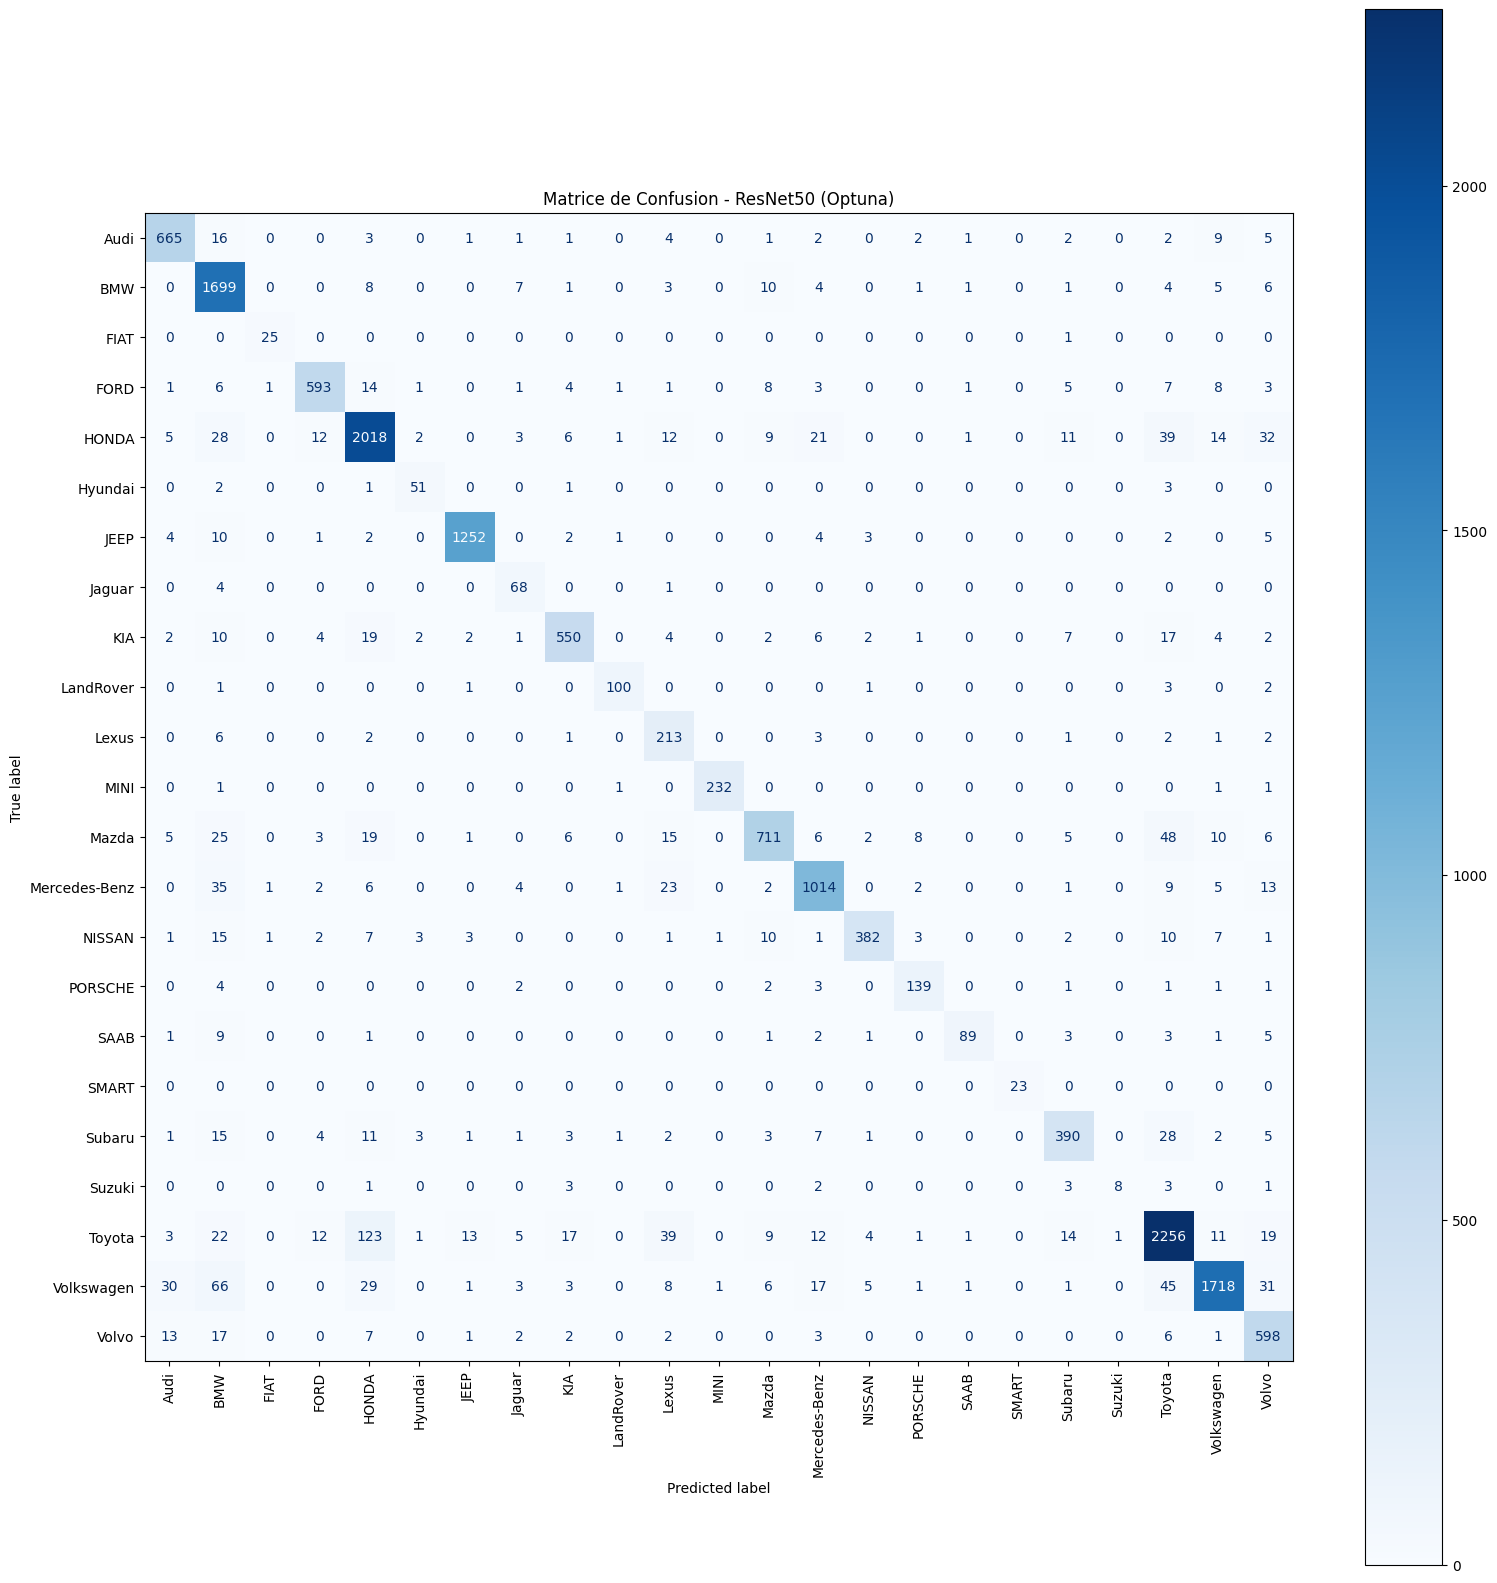

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. S'assurer que le modèle est en mode évaluation
model.eval()

all_preds = []
all_labels = []

print("Évaluation du modèle en cours sur le jeu de validation... Cela peut prendre quelques secondes.")

# 2. Récupérer toutes les prédictions
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # On rapatrie les données sur le CPU pour Scikit-Learn
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Rapport de classification (Accuracy & F1-score par classe)
print("\n" + "="*60)
print("📊 RAPPORT DE CLASSIFICATION")
print("="*60)
# 'class_names' contient déjà le nom de tes 23 marques
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

# 4. Matrice de confusion
print("\n" + "="*60)
print("🗺️ MATRICE DE CONFUSION")
print("="*60)
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# On ajuste la taille pour que les 23 classes soient lisibles
fig, ax = plt.subplots(figsize=(16, 16)) 
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')
plt.title("Matrice de Confusion - ResNet50 (Optuna)")
plt.tight_layout()
plt.show()

C:\Users\plled\AppData\Local\Temp\ipykernel_14308\2029668580.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_locat

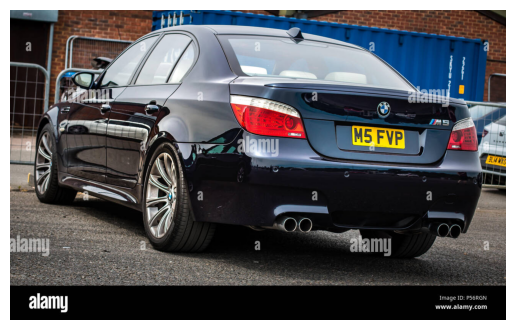

Résultat : BMW
Confiance : 99.91%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# 1. CONFIGURATION (Doit être identique à l'entraînement)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_path = "voiture8.jpeg"

# On récupère class_names depuis ton dataset (ou on le définit manuellement)
# class_names = [...] 

# On réutilise exactement tes val_transforms du script d'entraînement
img_size = (224, 224)
val_transforms = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. RECONSTRUCTION DE L'ARCHITECTURE EXACTE
def load_trained_model(checkpoint_path, num_classes):
    # On crée le même ResNet50
    model = models.resnet50() 
    
    # On reconstruit la "tête" EXACTEMENT comme dans ton build_car_model
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5416202525218761), # Le fameux index 0
        nn.Linear(num_ftrs, num_classes) # Le fameux index 1 (fc.1)
    )
    
    # Chargement des poids
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval() # Crucial pour désactiver le Dropout pendant le test
    return model

# 3. FONCTION DE PRÉDICTION
def predict_car(img_path, model, classes):
    img = Image.open(img_path).convert('RGB')
    
    # Affichage
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Prétraitement
    img_t = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_t)
        probs = F.softmax(outputs, dim=1)
        conf, classes_idx = torch.max(probs, 1)
        
    print(f"Résultat : {classes[classes_idx.item()]}")
    print(f"Confiance : {conf.item()*100:.2f}%")

# Lancement
num_classes = len(class_names)
trained_model = load_trained_model('best_car_model.pth', num_classes)
predict_car(image_path, trained_model, class_names)